# Investigating NOFIRST sources 

NOFIRST objects are defined in function `subjects.get_first_from_bbox`. These labels (and "normal" FIRST IDs) are associated with subjects during the initial subjects processing stage. This function does the following:
- For each bounding box,
    - get the centre coordinates and height/width
    - define this as a SkyCoord
    - find FIRST objects inside the bounding box using the entire catalogue list (`data/cache/first_2014Dec17.csv`).
    - If there are no FIRST objects inside, then mark this radio island as "NOFIRST". 
- Note: FIRSTTree is returned by `subjects.build_first_tree`. It's a tuple where the zeroth entry is a list of coordinates and the first entry a list of FIRST names (formatted like J072734.2+644059).

## BBoxes 

The keys in the bbox field are set in `process_subject` as follows:

```
bboxes = get_bboxes(raw_subject, cache)
bbox_to_firsts = {}
for bbox in bboxes:
    firsts = get_first_from_bbox(bbox, raw_subject, cache, first_tree)
    bbox_to_firsts[bbox] = firsts
s = Subject(id=sid, zid=zid, coords=raw_subject["coords"], bboxes=bbox_to_firsts)
```
The bboxes returned by `get_bboxes` are actually just those from the raw subject. So they're in some weird fucking coordinate system. Have to convert them to RA/Dec or just pixes in the image coordinate frame.

The function `get_first_from_bbox` has to transform them to a physical coordinate frame to x-match with FIRST.
It does this using `transform_bbox_px_to_phys` which transforms the coordinates to RA/Dec. 
It takes in a `raw_subject`

In [ ]:
%pip install ipympl ipywidgets
%matplotlib widget

/Users/u5708159/Projects/RGZII/rgzdr2/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from pathlib import Path

from rgz import subjects
from rgz import constants
from rgz import classifications
from rgz.plot import classifications as plot_classifications
from rgz.plot import subject as plot_subject

plt.ion()

In [15]:
# Paths 
cache_path = Path("data") / "cache"
testdata_path = Path("rgz") / "testdata"
raw_subjects_path = testdata_path / "subjects.json"
processed_subjects_path = testdata_path / "subjects_processed.json"
processed_classifications_path = testdata_path / "classifications_processed.json"

# TODO

- transform_coord_radio: where is this used? what does it need from raw_subject?
    - in contours.py, in function get_contours
        - this fn takes in a Subject so can get rid of reference to raw_subject
    - in subjects.py, in function transform_bbox_px_to_phys
        - transform_bbox_px_to_phys currently takes in a raw_subject. 
            - Can we get it to take in a Subject instead? OR a class variable that is common to both? 

    - transform_bbox_px_to_phys is only used in get_first_from_bbox
        get_first_from_bbox
            transform_bbox_px_to_phys
                transform_coord_radio
                    fetch_first_image_from_server_or_cache


Can we remove references to raw_subject from fetch_first_image_from_server_or_cache?

In [ ]:
def transform_bbox_px_to_phys(
    px_bbox: subjects.BBox, subject: subjects.Subject, cache: Path
) -> npt.NDArray[np.float64]:
    """Transforms a bbox from pixel coordinates to RA/dec."""
    xmin, ymin, xmax, ymax = px_bbox
    # Flip vertically.
    phys_bbox = np.array(
        [xmin, constants.RADIO_MAX_PX - ymax, xmax, constants.RADIO_MAX_PX - ymin]
    )
    return np.concatenate(
        [
            subjects.transform_coord_radio(
                coord=phys_bbox[:2], raw_subject=None, subject=subject, cache=cache
            ),
            subjects.transform_coord_radio(
                coord=p hys_bbox[2:], raw_subject=None, subject=subject, cache=cache
            ),
        ]
    )

In [16]:
with open(processed_subjects_path, "r") as f:
    subject_instances = [subjects.Subject.from_json(s) for s in json.load(f)]

In [17]:
subject_instances

[Subject(id='52af7eb58c51f405a60012e6', zid='ARG0002zwe', coords=[150.16704166666668, 10.93888888888889], bbox_list=[[71.7, 75.8, 62.7, 61.9]], phys_bbox_list=[[150.16506849846445, 10.940342101013552, 150.16853771112253, 10.935075069998149]], bboxes={(71.7, 75.8, 62.7, 61.9): ['FIRST_J100040.0+105612', 'FIRST_J100040.0+105620']}),
 Subject(id='52af7eb58c51f405a60012ee', zid='ARG0002zwm', coords=[150.16666666666666, 10.936805555555555], bbox_list=[[70.7, 70.8, 61.7, 56.9]], phys_bbox_list=[[150.16494498297618, 10.940236106468516, 150.16841419659562, 10.93496907684831]], bboxes={(70.7, 70.8, 61.7, 56.9): ['FIRST_J100040.0+105612', 'FIRST_J100040.0+105620']}),
 Subject(id='52af80ff7aa69f059a001478', zid='ARG000307k', coords=[150.78608333333332, 10.846722222222223], bbox_list=[[73.5, 73.9, 59.7, 61.0]], phys_bbox_list=[[150.7829756629446, 10.848725477143402, 150.78829743062798, 10.843838492680884]], bboxes={(73.5, 73.9, 59.7, 61.0): ['FIRST_J100308.6+105048']}),
 Subject(id='52af81007aa69f

In [18]:
subject_instances_nofirst = []
for s in subject_instances:
    for _, first_ids in s.bboxes.items():
        if any([first_id.startswith("NOFIRST") for first_id in first_ids]):
            subject_instances_nofirst.append(s)
            continue

{(36.0, 12.2, 28.9, 4.7): ['FIRST_J100030.2+100804'], (72.9, 76.6, 54.9, 55.5): ['FIRST_J100027.0+100644'], (75.8, 74.4, 73.5, 72.2): ['NOFIRST_J100026.31664804+100635.58059235'], (88.3, 74.8, 79.5, 70.9): ['FIRST_J100025.2+100637']}


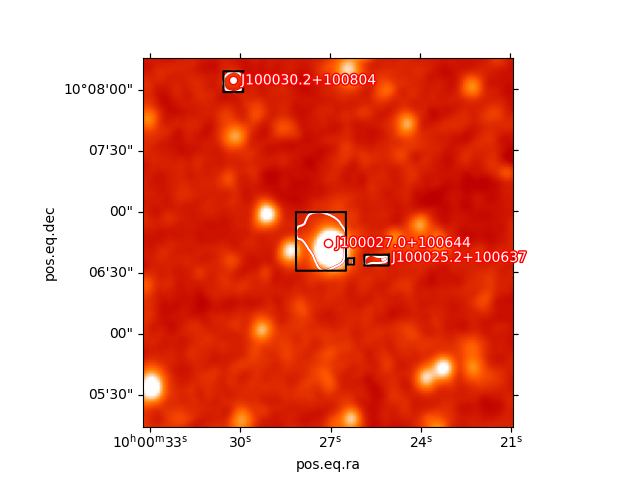

In [20]:
# Plot a subject 
s = subject_instances_nofirst[2]
print(s.bboxes)
ax = plot_subject.plot_single_subject(subject=s, cache=cache_path, ax=None)

"""
    # TODO(MatthewJA): Also use the contours to ensure that they really are within the boxes.
    phys_bbox = transform_bbox_px_to_phys(px_bbox, raw_subject, cache)
    # Find the centre...
    centre = (phys_bbox[::2].mean(), phys_bbox[1::2].mean())
    # ...and the width and height.
    width = abs(phys_bbox[2] - phys_bbox[0]).to(u.arcsec)
    height = abs(phys_bbox[3] - phys_bbox[1]).to(u.arcsec)

    xmin, ymin, xmax, ymax
"""
for phys_bbox in s.phys_bbox_list:
    xmin, ymin, xmax, ymax = phys_bbox
    # Plot bounding box
    ax.plot([xmin, xmin, xmax, xmax, xmin],
            [ymin, ymax, ymax, ymin, ymin], 
            color="k", transform=ax.get_transform("fk5"))

# for bbox in list(s.bboxes.keys()):
#     first_ids = s.bboxes[bbox]
#     bbox_coords = transform_bbox_px_to_phys(bbox, s, cache=cache_path)
#     xmin, ymin, xmax, ymax = [c.value for c in bbox_coords]
#     ra_centre, dec_centre = (xmax - xmin) / 2, (ymax - ymin) / 2

#     # Plot bounding box
#     ax.plot([xmin, xmin, xmax, xmax, xmin],
#             [ymin, ymax, ymax, ymin, ymin], 
#             color="k", transform=ax.get_transform("fk5"))

#     for first_id in first_ids:
#         # if first_id.startswith("NO"):
#         # I do not know why this is not working fml
#         ax.annotate(
#             first_id,
#             (ra_centre, dec_centre),
#             xycoords=ax.get_transform("fk5"),
#             xytext=(6, -3),
#             color="green",
#             textcoords="offset points",
#             transform=ax.get_transform("fk5")
#         )


In [ ]:
xmin.value

In [ ]:
xmin

In [ ]:
bbox = list(s.bboxes.keys())[0]
bbox_coords = transform_bbox_px_to_phys(bbox, s, cache=cache_path)

In [ ]:
xmin, ymin, xmax, ymax = bbox_coords

In [ ]:
ymax

In [ ]:
# Load a subject 
subject_idx = 11
with open(processed_subjects_path, "r") as f:
    subject_json = json.load(f)[subject_idx]
subject = subjects.Subject.from_json(subject_json)
print(subject.id)

# Find a classification that references this subject 
with open(processed_classifications_path, "r") as f:
    classifications_json = [c for c in json.load(f) if c["zid"] == subject.zid]
classifications_list = [classifications.Classification.from_json(cs) for cs in classifications_json]


In [ ]:
# Test general functionality
for ii in range(len(classifications_list))[:1]:
    ax = plot_classifications.plot_single_classification(classification=classifications_list[ii], 
                                            subject=subject,
                                            cache=testdata_path / "first",
                                            ax=None)